# Results by Köppen-Geiger Climate Class — v2

> **v2 changes:** added a *Calibration filter & sort* section (2b) that lets you drop regions with poor HBV calibration and sort by `KGE`, `NSE`, or the `Nelder-Mead` objective. All downstream plots and tables respect the filter.

Loads **all** `results.json` files found under `regions/`, assigns each catchment its
dominant Köppen-Geiger class (highest coverage %), and visualises how the once-in-100-year
discharge shifts across climate scenarios — grouped and coloured by KG class.

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

from rich import print

# ── Scenario display order (same as preliminary_results) ──────────────────────
SCENARIO_ORDER = [
    'CMIP6 hist',
    'ERA5',
    'DestinE hist',
    'SSP1-2.6',
    'SSP2-4.5',
    'SSP3-7.0',
    'SSP5-8.5',
    'DestinE future',
]

# ── Major KG group colours (standard palette) ─────────────────────────────────
KG_GROUP_COLOR = {
    'A': '#1565C0',   # Tropical  — blue
    'B': '#E65100',   # Arid      — deep orange
    'C': '#2E7D32',   # Temperate — green
    'D': '#6A1B9A',   # Continental — purple
    'E': '#00838F',   # Polar     — teal
}
KG_GROUP_LABEL = {
    'A': 'A — Tropical',
    'B': 'B — Arid',
    'C': 'C — Temperate',
    'D': 'D — Continental',
    'E': 'E — Polar',
}

# ── Calibration filtering / sorting (v2) ──────────────────────────────────────
# Each results.json has a flat 'calibration_HBV' dict like:
#     {'Nelder-Mead': 0.48, 'KGE': 0.26, 'NSE': -0.51, 'period': '...'}
#
# Conventions used below:
#   • KGE         — higher is better (1.0 = perfect)
#   • NSE         — higher is better (1.0 = perfect)
#   • Nelder-Mead — the objective value the optimizer minimised
#                   (looks like 1 - KGE in your data → LOWER is better).
#                   Flip CALIB_HIGHER_IS_BETTER['Nelder-Mead'] = True if your
#                   convention is the other way around.
CALIB_METRICS = ['KGE', 'NSE', 'Nelder-Mead']
CALIB_HIGHER_IS_BETTER = {
    'KGE':         True,
    'NSE':         True,
    'Nelder-Mead': False,   # objective value to minimise
}

# Default sort/filter — change these and re-run the notebook
SORT_BY_METRIC   = 'KGE'    # one of CALIB_METRICS
MIN_KGE          = None     # e.g. 0.5 to drop regions with KGE < 0.5
MIN_NSE          = None     # e.g. 0.0
MAX_NELDER_MEAD  = None     # e.g. 0.5 (only keep regions with NM <= 0.5)

# ── ERA5 return-period sanity filter (v2.1) ───────────────────────────────────
# Each region has an ERA5-driven historical run; we computed the return period
# at which that run reaches the *observed* Q100. A well-calibrated model should
# give a value close to 100 years. Big deviations (e.g. ERA5 says the observed
# Q100 has a return period of 5 years, or 10000 years) mean the model isn't
# representing extremes well, even if KGE/NSE on daily flows look fine.
#
# Set both to None to skip this filter.
MIN_ERA5_RP_Q100 = 75     # e.g. 75   — drop regions where ERA5 RP < 75 years
MAX_ERA5_RP_Q100 = 125     # e.g. 125  — drop regions where ERA5 RP > 125 years


## 1. Load all results

In [2]:
def parse_rp(value):
    """Return (mean, std) for a return-period value (plain number or 'mean ± std' string)."""
    if isinstance(value, (int, float)):
        return float(value), 0.0
    s = str(value)
    if '\u00b1' in s:
        parts = s.split('\u00b1')
        return float(parts[0].strip()), float(parts[1].strip())
    return float(s.strip()), 0.0


def get_scenario_label(key):
    """Map a results.json key to a short display label and display order."""
    k = key.lower()
    if 'modelled discharge' in k or ('cmip' in k and 'ssp' not in k):
        return 'CMIP6 hist', 0
    if k == 'era5':
        return 'ERA5', 1
    if 'destine' in k and ('hist' in k or 'historical' in k):
        return 'DestinE hist', 2
    if 'ssp126' in k:
        return 'SSP1-2.6', 3
    if 'ssp245' in k:
        return 'SSP2-4.5', 4
    if 'ssp370' in k:
        return 'SSP3-7.0', 5
    if 'ssp585' in k:
        return 'SSP5-8.5', 6
    if 'destine' in k:
        return 'DestinE future', 7
    return None, 99


def dominant_kg(kg_dict):
    """Return the KG class code with the highest catchment coverage."""
    return max(kg_dict, key=kg_dict.get)


# ── Walk every region directory ───────────────────────────────────────────────
base_path = Path('regions')
all_results = []
skipped = []

for results_file in sorted(base_path.rglob('results.json')):
    country = results_file.parts[-3]   # regions/<country>/<region>/results.json
    region  = results_file.parts[-2]

    with open(results_file) as f:
        data = json.load(f)

    # Minimum required keys
    if not {'return_periods_HBV', 'koppen_geiger', 'catchment_area_km2', 'calibration_HBV'} <= data.keys():
        skipped.append(f"{country}/{region}  (missing required keys)")
        # print(f'[red]✗[/red] {country:30s} / {region}  [dim](incomplete)[/dim]')
        continue

    if 'observed_reference' not in data['return_periods_HBV']:
        skipped.append(f"{country}/{region}  (no observed_reference)")
        # print(f'[red]✗[/red] {country:30s} / {region}  [dim](no observed_reference)[/dim]')
        continue

    data['country'] = country
    data['region']  = region
    data['kg_dominant'] = dominant_kg(data['koppen_geiger'])
    data['kg_group']    = data['kg_dominant'][0]   # first letter: A/B/C/D/E
    all_results.append(data)
    # print(f'[green]✓[/green] {country:30s} / {region}  '
    #       f'[cyan]{data["kg_dominant"]}[/cyan]')

print(f'\n[bold]{len(all_results)} region(s) loaded.[/bold]')
# if skipped:
#     print(f'[yellow]{len(skipped)} skipped:[/yellow]')
#     for s in skipped:
#         print(f'  [dim]· {s}[/dim]')

688 region(s) loaded.

## 2. Build DataFrame

In [3]:
rows = []
for r in all_results:
    rp_dict = r['return_periods_HBV']
    obs = rp_dict['observed_reference']
    q100_mm_d = float(obs.get('q100_mm_d', 0.0))

    # ── Pull calibration scores (v2) ──────────────────────────────────────────
    calib = r.get('calibration_HBV', {}) or {}
    cal_kge = calib.get('KGE')
    cal_nse = calib.get('NSE')
    cal_nm  = calib.get('Nelder-Mead')

    for key, vals in rp_dict.items():
        if key == 'observed_reference':
            continue
        rp_val = vals.get('rp_at_obs_q100') if isinstance(vals, dict) else None
        if rp_val is None:
            continue
        label, order = get_scenario_label(key)
        if label is None:
            continue
        mean, std = parse_rp(rp_val)
        rows.append({
            'country':            r['country'],
            'region':             r['region'],
            'caravan_id':         r['caravan_id'],
            'catchment_area_km2': r['catchment_area_km2'],
            'kg_dominant':        r['kg_dominant'],
            'kg_group':           r['kg_group'],
            'scenario_label':     label,
            'order':              order,
            'rp_mean':            mean,
            'rp_std':             std,
            'q100_mm_d':          q100_mm_d,
            'q100_m3s':           q100_mm_d * r['catchment_area_km2'] / 86.4,
            # ── calibration scores (v2) ────────────────────────────────────────
            'KGE':                cal_kge,
            'NSE':                cal_nse,
            'Nelder-Mead':        cal_nm,
        })

df = (pd.DataFrame(rows)
        .sort_values(['kg_group', 'kg_dominant', 'region', 'order'])
        .reset_index(drop=True))
# print(df[['country', 'region', 'kg_dominant', 'scenario_label', 'rp_mean',
#           'KGE', 'NSE', 'Nelder-Mead']].to_string())


## 2b. Filter & sort by calibration quality (v2)

Each region was calibrated with HBV; the resulting `KGE`, `NSE`, and `Nelder-Mead`
objective values are now columns on `df`. Use this section to:

- **filter out** regions whose calibration is too poor to trust
- **filter out** regions whose ERA5-driven historical run gives an implausible return period for the observed Q100 (a well-calibrated model should give ~100 years)
- **sort** regions by any of the three metrics
- see a quick summary table

Adjust `MIN_KGE`, `MIN_NSE`, `MAX_NELDER_MEAD`, `MIN_ERA5_RP_Q100` / `MAX_ERA5_RP_Q100`, and `SORT_BY_METRIC` in the
config cell at the top of the notebook, then re-run from here downwards.

In [4]:
# ── Per-region calibration table ──────────────────────────────────────────────
# One row per region. We also pull the ERA5-driven Q100 return period as a
# per-region column (it's the same value for every scenario row in df, so we
# extract it from the rows where scenario_label == "ERA5").
calib_df = (
    df[['country', 'region', 'kg_dominant', 'kg_group',
        'KGE', 'NSE', 'Nelder-Mead']]
    .drop_duplicates(subset='region')
    .reset_index(drop=True)
)

# Attach ERA5 RP100 as a new column (NaN for regions without an ERA5 row)
era5_rp = (
    df[df['scenario_label'] == 'ERA5'][['region', 'rp_mean']]
    .drop_duplicates(subset='region')
    .rename(columns={'rp_mean': 'ERA5_RP100'})
)
calib_df = calib_df.merge(era5_rp, on='region', how='left')

n_total = len(calib_df)

# ── Apply thresholds ──────────────────────────────────────────────────────────
mask = pd.Series(True, index=calib_df.index)
if MIN_KGE         is not None: mask &= calib_df['KGE']         >= MIN_KGE
if MIN_NSE         is not None: mask &= calib_df['NSE']         >= MIN_NSE
if MAX_NELDER_MEAD is not None: mask &= calib_df['Nelder-Mead'] <= MAX_NELDER_MEAD
if MIN_ERA5_RP_Q100 is not None: mask &= calib_df['ERA5_RP100'] >= MIN_ERA5_RP_Q100
if MAX_ERA5_RP_Q100 is not None: mask &= calib_df['ERA5_RP100'] <= MAX_ERA5_RP_Q100

kept = calib_df[mask].copy()
n_kept = len(kept)

# ── Sort by chosen metric (best first) ────────────────────────────────────────
ascending = not CALIB_HIGHER_IS_BETTER[SORT_BY_METRIC]
kept = kept.sort_values(SORT_BY_METRIC, ascending=ascending).reset_index(drop=True)

print(f'[bold]Calibration filter:[/bold] kept [green]{n_kept}[/green] / {n_total} regions')
if MIN_KGE          is not None: print(f'  \u00b7 KGE \u2265 {MIN_KGE}')
if MIN_NSE          is not None: print(f'  \u00b7 NSE \u2265 {MIN_NSE}')
if MAX_NELDER_MEAD  is not None: print(f'  \u00b7 Nelder-Mead \u2264 {MAX_NELDER_MEAD}')
if MIN_ERA5_RP_Q100 is not None or MAX_ERA5_RP_Q100 is not None:
    lo = MIN_ERA5_RP_Q100 if MIN_ERA5_RP_Q100 is not None else '-\u221e'
    hi = MAX_ERA5_RP_Q100 if MAX_ERA5_RP_Q100 is not None else '\u221e'
    print(f'  \u00b7 ERA5 RP100 \u2208 [{lo}, {hi}] years')
print(f'[bold]Sorted by:[/bold] {SORT_BY_METRIC} '
      f'({"ascending" if ascending else "descending"})')

# Show the table with ERA5 RP100 alongside the calibration scores
display_cols = ['country', 'region', 'kg_dominant',
                'KGE', 'NSE', 'Nelder-Mead', 'ERA5_RP100']
kept[display_cols].style \
    .format({'KGE': '{:.3f}', 'NSE': '{:.3f}',
             'Nelder-Mead': '{:.3f}', 'ERA5_RP100': '{:.1f}'}) \
    .background_gradient(cmap='RdYlGn',   subset=['KGE', 'NSE'], vmin=-1, vmax=1) \
    .background_gradient(cmap='RdYlGn_r', subset=['Nelder-Mead'], vmin=0,  vmax=1) \
    .set_caption(f'Per-region HBV calibration scores + ERA5 RP100 \u2014 sorted by {SORT_BY_METRIC}')


Calibration filter: kept 91 / 688 regions

· ERA5 RP100 ∈ [75, 125] years

Sorted by: KGE (descending)

,country,region,kg_dominant,KGE,NSE,Nelder-Mead,ERA5_RP100
0,canada,hysets_01AD003,Dfb,0.883,0.792,0.221,81.2
1,switzerland,lamah_2141,ET,0.838,0.688,0.399,109.7
2,austria,lamah_201160,ET,0.835,0.678,0.283,80.2
3,chile,camelscl_9135001,Cfb,0.821,0.647,1.014,112.8
4,austria,lamah_200048,Dfc,0.818,0.652,0.508,85.0
5,austria,lamah_203166,Dfc,0.803,0.606,0.498,109.5
6,austria,lamah_201723,Dfc,0.802,0.613,0.355,87.4
7,germany,lamah_1122,Dfb,0.797,0.675,0.035,76.8
8,england,camelsgb_40011,Cfb,0.763,0.584,0.160,83.4
9,chile,camelscl_10363002,Cfb,0.762,0.558,0.390,102.7


### Apply the filter to `df`

The cell below restricts `df` (the long-form scenario table used by every
plot below) to only the regions that survived the calibration filter, in the
sorted order chosen above. **All downstream plots and tables therefore
respect the filter automatically.** Comment out the assignment if you want
to keep the unfiltered `df`.

In [5]:
# Restrict df to the kept regions, preserving the sort order from `kept`.
region_order = kept['region'].tolist()
region_rank  = {r: i for i, r in enumerate(region_order)}

df = (
    df[df['region'].isin(region_order)]
    .assign(_region_rank=lambda d: d['region'].map(region_rank))
    .sort_values(['_region_rank', 'order'])
    .drop(columns='_region_rank')
    .reset_index(drop=True)
)

# Quick sanity check on the calibration distribution that's left
summary = (
    kept[['KGE', 'NSE', 'Nelder-Mead']]
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(3)
)
print(summary)

print(f'\n[bold]df now contains {df["region"].nunique()} regions, '
      f'{len(df)} scenario rows.[/bold]')


KGE     NSE  Nelder-Mead
count   86.000  86.000       91.000
mean     0.504   0.228          inf
median   0.500   0.247        0.678
min      0.058  -0.444        0.035
max      0.883   0.792          inf

df now contains 91 regions, 728 scenario rows.

## 3. Plot — return-period shift, coloured by KG group

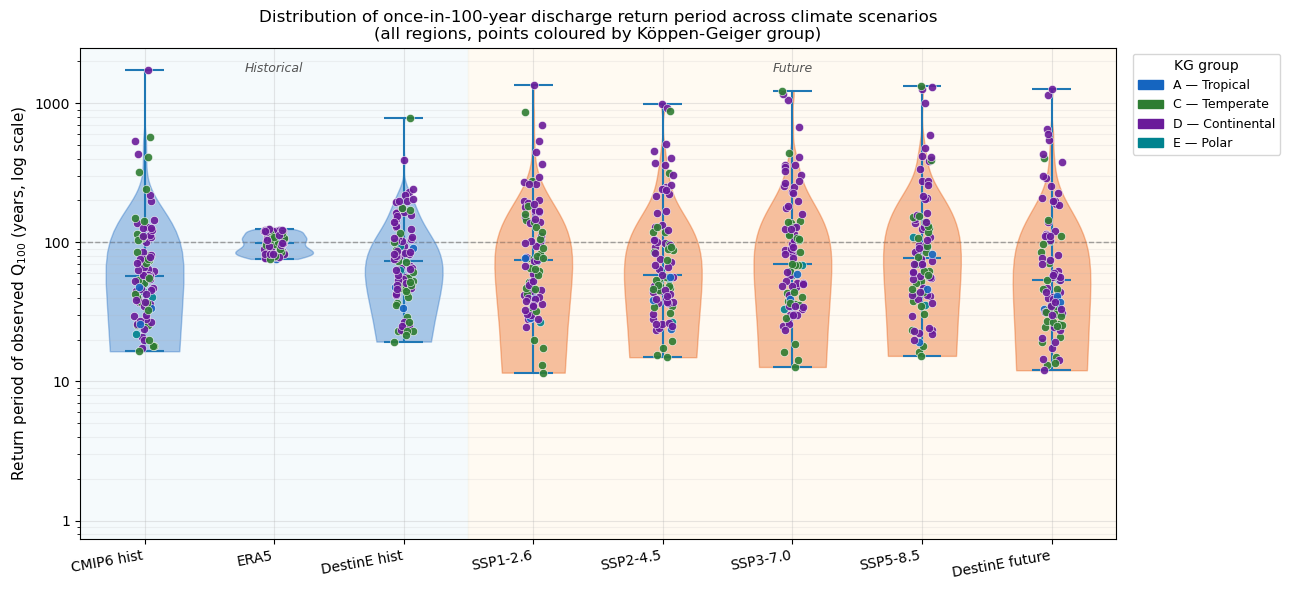

In [9]:
label_to_x = {lbl: i for i, lbl in enumerate(SCENARIO_ORDER)}

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_yscale('log')
ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.4, zorder=1)

ax.axvspan(-0.5, 2.5, color='#e8f4f8', alpha=0.4, zorder=0)
ax.axvspan(2.5, len(SCENARIO_ORDER) - 0.5, color='#fff3e0', alpha=0.4, zorder=0)
ax.text(1.0, 0.97, 'Historical', transform=ax.get_xaxis_transform(),
        ha='center', va='top', color='#555', fontsize=9, style='italic')
ax.text(5.0, 0.97, 'Future', transform=ax.get_xaxis_transform(),
        ha='center', va='top', color='#555', fontsize=9, style='italic')

# Build dataset per scenario (only include scenarios that have data)
datasets, positions = [], []
for i, scen in enumerate(SCENARIO_ORDER):
    vals = df[df['scenario_label'] == scen]['rp_mean'].dropna().values
    if len(vals) > 0:
        datasets.append(vals)
        positions.append(i)

parts = ax.violinplot(datasets, positions=positions, showmedians=True, showextrema=True, widths=0.6)

# Colour violin bodies: historical = blue, future = orange
for j, pc in enumerate(parts['bodies']):
    color = '#1565C0' if positions[j] <= 2 else '#E65100'
    pc.set_facecolor(color)
    pc.set_alpha(0.35)
    pc.set_edgecolor(color)
for partname in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
    if partname in parts:
        parts[partname].set_linewidth(1.5)

# Overlay individual points coloured by KG group
rng = np.random.default_rng(42)
for i, scen in enumerate(SCENARIO_ORDER):
    sub = df[df['scenario_label'] == scen]
    jitter = rng.uniform(-0.08, 0.08, size=len(sub))
    for (_, row), jit in zip(sub.iterrows(), jitter):
        color = KG_GROUP_COLOR.get(row['kg_group'], '#888888')
        ax.scatter(i + jit, row['rp_mean'], color=color, s=35, zorder=4,
                   alpha=0.9, edgecolors='white', linewidths=0.4)

ax.set_xticks(range(len(SCENARIO_ORDER)))
ax.set_xticklabels(SCENARIO_ORDER, fontsize=10, rotation=10, ha='right')
ax.set_ylabel('Return period of observed Q$_{100}$ (years, log scale)', fontsize=11)
ax.set_title(
    'Distribution of once-in-100-year discharge return period across climate scenarios\n'
    '(all regions, points coloured by Köppen-Geiger group)',
    fontsize=12,
)
ax.set_xlim(-0.5, len(SCENARIO_ORDER) - 0.5)
# ax.set_ylim(1, 1e3)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)

kg_patches = [mpatches.Patch(color=c, label=KG_GROUP_LABEL[g])
              for g, c in KG_GROUP_COLOR.items() if g in df['kg_group'].values]
ax.legend(handles=kg_patches, title='KG group', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig("KG_rp_all.png")
plt.show()

## 4. Plot per KG group

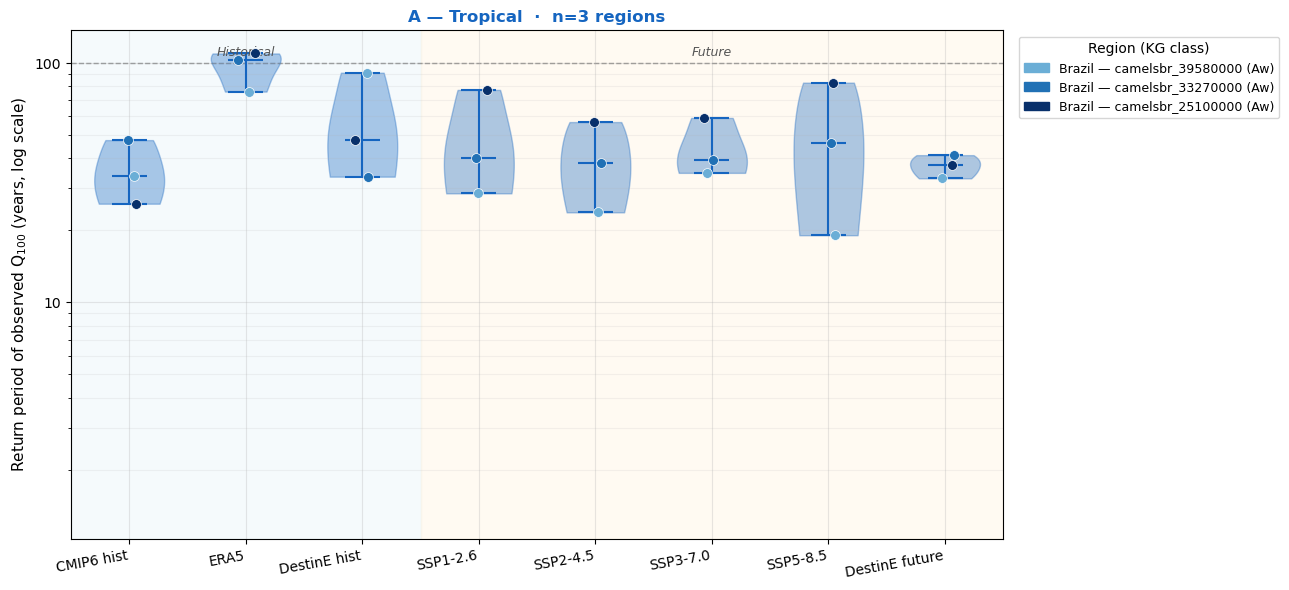

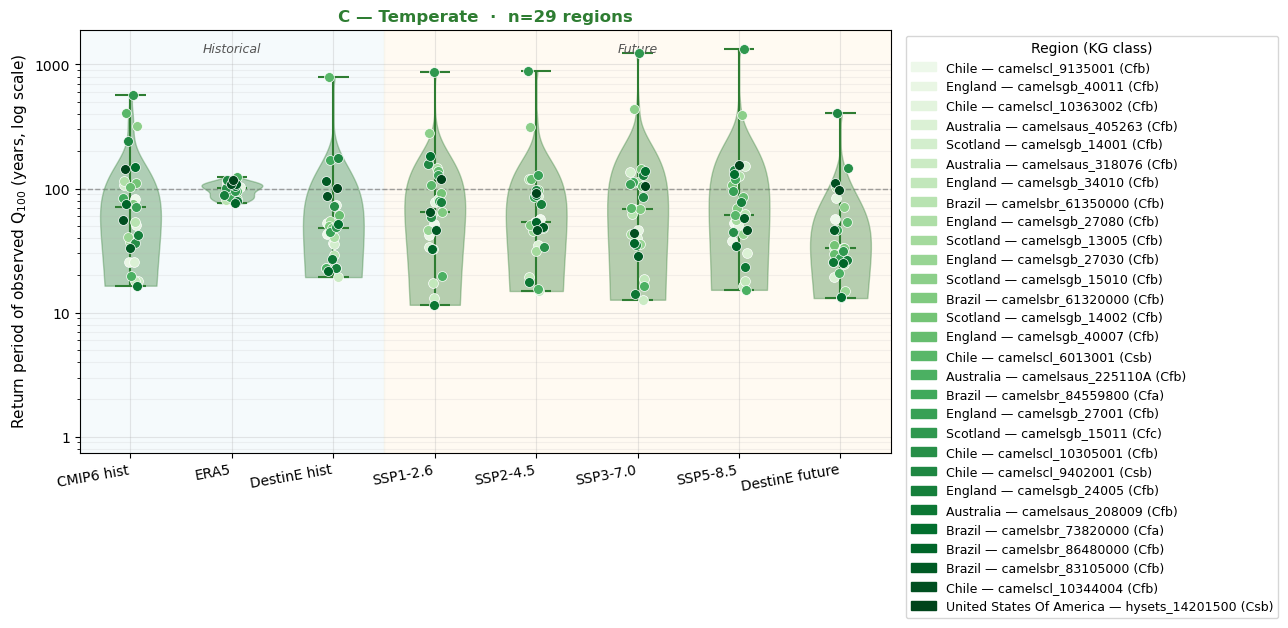

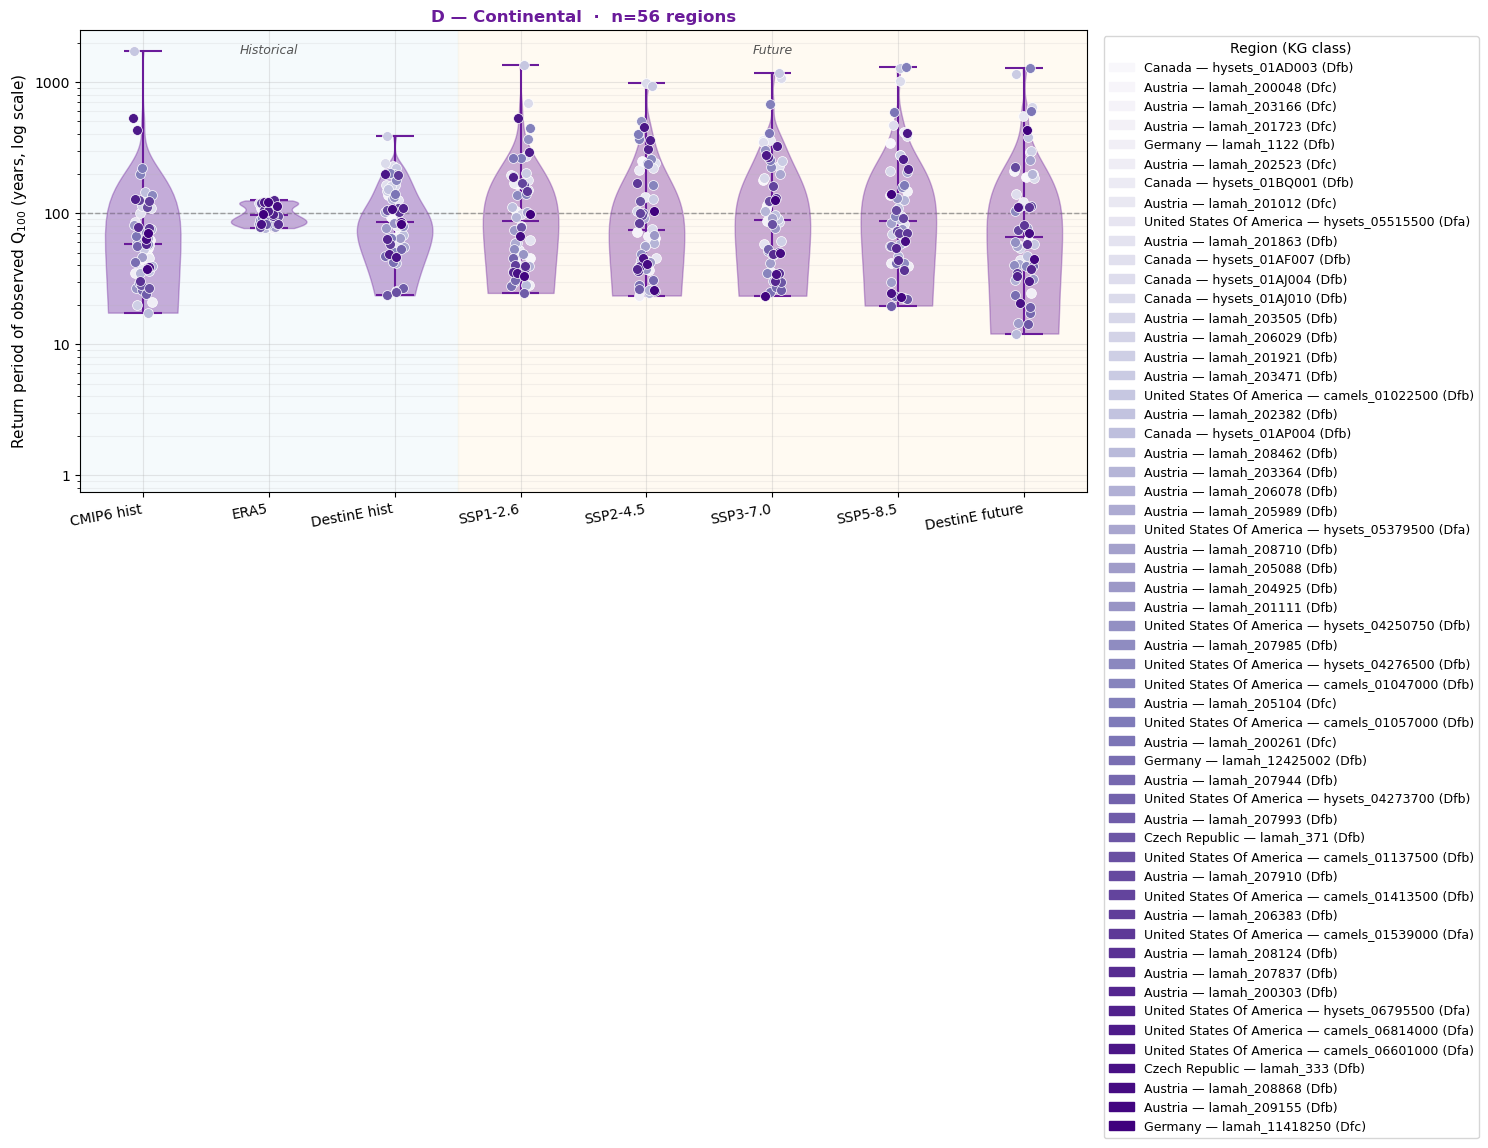

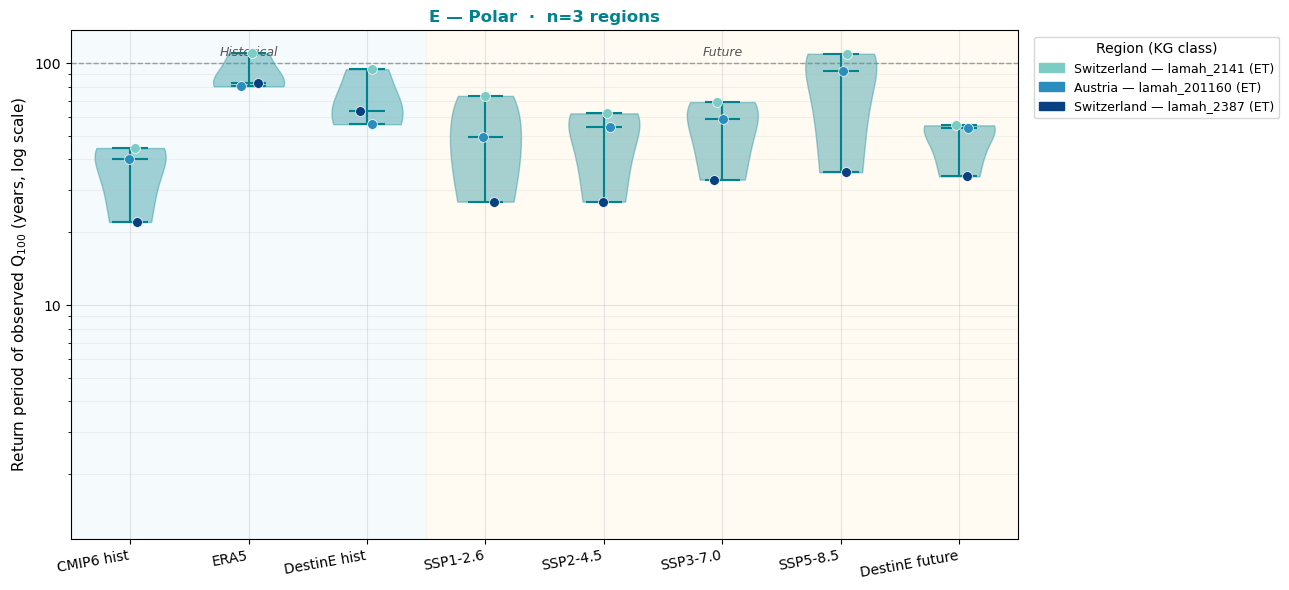

In [13]:
kg_groups_present = sorted(df['kg_group'].unique())
out_dir = Path('figures')
out_dir.mkdir(exist_ok=True)

for kg_group in kg_groups_present:
    subset = df[df['kg_group'] == kg_group]
    if subset.empty:
        continue

    regions = subset['region'].unique()
    color = KG_GROUP_COLOR.get(kg_group, '#888888')

    cmap = plt.cm.get_cmap(
        'Blues'   if kg_group == 'A' else
        'Oranges' if kg_group == 'B' else
        'Greens'  if kg_group == 'C' else
        'Purples' if kg_group == 'D' else 'GnBu',
        len(regions) + 2,
    )
    region_colors = {r: cmap(i + 2) for i, r in enumerate(regions)}

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.set_yscale('log')
    ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.4, zorder=1)
    ax.axvspan(-0.5, 2.5, color='#e8f4f8', alpha=0.4, zorder=0)
    ax.axvspan(2.5, len(SCENARIO_ORDER) - 0.5, color='#fff3e0', alpha=0.4, zorder=0)
    ax.text(1.0, 0.97, 'Historical', transform=ax.get_xaxis_transform(),
            ha='center', va='top', color='#555', fontsize=9, style='italic')
    ax.text(5.0, 0.97, 'Future', transform=ax.get_xaxis_transform(),
            ha='center', va='top', color='#555', fontsize=9, style='italic')

    # Build violin dataset (need >1 point per scenario for a meaningful violin)
    datasets, positions = [], []
    for i, scen in enumerate(SCENARIO_ORDER):
        vals = subset[subset['scenario_label'] == scen]['rp_mean'].dropna().values
        if len(vals) > 1:
            datasets.append(vals)
            positions.append(i)

    if datasets:
        parts = ax.violinplot(datasets, positions=positions, showmedians=True,
                              showextrema=True, widths=0.6)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.35)
            pc.set_edgecolor(color)
        for partname in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
            if partname in parts:
                parts[partname].set_color(color)
                parts[partname].set_linewidth(1.5)

    # Always overlay individual points coloured by region (important for small n)
    rng = np.random.default_rng(42)
    for i, scen in enumerate(SCENARIO_ORDER):
        sub = subset[subset['scenario_label'] == scen]
        jitter = rng.uniform(-0.08, 0.08, size=len(sub))
        for (_, row), jit in zip(sub.iterrows(), jitter):
            rc = region_colors[row['region']]
            ax.scatter(i + jit, row['rp_mean'], color=rc, s=50, zorder=4,
                       edgecolors='white', linewidths=0.5)

    ax.set_xticks(range(len(SCENARIO_ORDER)))
    ax.set_xticklabels(SCENARIO_ORDER, fontsize=10, rotation=10, ha='right')
    ax.set_ylabel('Return period of observed Q$_{100}$ (years, log scale)', fontsize=11)
    ax.set_title(
        f'{KG_GROUP_LABEL.get(kg_group, kg_group)}  ·  n={len(regions)} regions',
        fontsize=12, color=color, fontweight='bold',
    )
    ax.set_xlim(-0.5, len(SCENARIO_ORDER) - 0.5)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.grid(True, which='major', alpha=0.3)
    ax.grid(True, which='minor', alpha=0.15)

    region_patches = [
        mpatches.Patch(
            color=region_colors[r],
            label=(f"{subset[subset['region']==r]['country'].iloc[0].replace('_',' ').title()}"
                   f" — {r} ({subset[subset['region']==r]['kg_dominant'].iloc[0]})")
        )
        for r in regions
    ]
    ax.legend(handles=region_patches, bbox_to_anchor=(1.01, 1), loc='upper left',
              fontsize=9, framealpha=0.8, title='Region (KG class)')
    
    plt.tight_layout()

    fig.savefig(out_dir / f'rp_violin_kg_{kg_group}.png', dpi=200, bbox_inches='tight')
    plt.show()

## 5. Summary table — mean return period per KG group × scenario

In [8]:
pivot = df.pivot_table(
    index='kg_dominant',
    columns='scenario_label',
    values='rp_mean',
    aggfunc='mean',
)
present_cols = [c for c in SCENARIO_ORDER if c in pivot.columns]
pivot = pivot[present_cols]

# Add region count and KG group letter as context columns
counts = df.groupby('kg_dominant')['region'].nunique().rename('n_regions')
pivot.insert(0, 'n_regions', counts)

pivot.index.name = 'KG class (dominant)'

pivot.style \
    .format({'n_regions': '{:.0f}'}) \
    .format({c: '{:.1f}' for c in present_cols}) \
    .background_gradient(cmap='RdYlGn_r', subset=present_cols, axis=None, vmin=50, vmax=200) \
    .set_caption(
        'Mean return period (years) of the observed Q\u2081\u2080\u2080 discharge '
        'per dominant KG class — > 100 \u2192 rarer event; < 100 \u2192 more frequent'
    )

scenario_label,n_regions,CMIP6 hist,ERA5,DestinE hist,SSP1-2.6,SSP2-4.5,SSP3-7.0,SSP5-8.5,DestinE future
KG class (dominant),,,,,,,,,
Aw,3,35.8,96.3,57.4,48.6,39.6,44.4,49.4,37.2
Cfa,2,117.2,95.4,110.9,131.1,87.2,126.2,124.5,30.0
Cfb,23,66.6,98.1,45.8,70.4,67.7,77.5,73.7,45.0
Cfc,1,567.3,95.5,49.2,866.0,878.5,1230.6,1339.2,31.6
Csb,3,264.3,110.1,355.2,127.9,79.7,87.0,119.1,184.6
Dfa,6,219.7,108.2,110.8,235.1,237.6,213.5,203.4,59.4
Dfb,42,105.6,98.3,109.6,141.1,146.3,151.2,159.5,135.6
Dfc,8,71.0,100.0,108.5,158.0,133.9,239.3,339.4,411.6
ET,3,35.7,90.9,71.2,49.8,47.8,53.6,79.2,47.8
